## Tinh chỉnh (hyperparameter tuning)

### Import thư viện

In [1]:
import os
import sys
import random
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Machine Learning utilities
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold,
    cross_val_score, 
    RandomizedSearchCV, 
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
params = {}

# Thư mục thí nghiệm
params["exps_dir"]  = "../exps"
params["exp_name"]  = "challenge3_musicgenre_tuning"
params["save_dir"]  = f'{params["exps_dir"]}/result1_{params["exp_name"]}'

# Đường dẫn dữ liệu đã preprocess (before FE)
params["data_path"] = f'{params["exps_dir"]}/data/train_fe_pre.xlsx'
params["test_path"] = f'{params["exps_dir"]}/data/test_fe_pre.xlsx'

params["k_fold"] = 10
params["random_state"] = 42

os.makedirs(params["save_dir"], exist_ok=True)

random.seed(params["random_state"])
np.random.seed(params["random_state"])
os.environ["PYTHONHASHSEED"] = str(params["random_state"])

print("Save dir:", params["save_dir"])
print("Train path:", params["data_path"])
print("Test path :", params["test_path"])

Save dir: ../exps/result1_challenge3_musicgenre_tuning
Train path: ../exps/data/train_fe_pre.xlsx
Test path : ../exps/data/test_fe_pre.xlsx


### Load dữ liệu

In [3]:
# Đọc dữ liệu sau Feature Engineering
train = pd.read_excel(params["data_path"])
test  = pd.read_excel(params["test_path"])

print("Đọc dữ liệu thành công:", train.shape, test.shape)
train.head()

Đọc dữ liệu thành công: (14396, 32) (3600, 31)


,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,mood_balance,acoustic_instru,tempo_medium,tempo_fast,is_major,key_norm,tempo_sq,loudness_sq,valence_sq,Class
0,0.363636,0.295244,0.535438,0.8,0.806485,0,0.016729,0.379518,0.003935,0.096011,...,0.383093,0.000000,False,True,0,0.8,0.481286,0.027691,0.056356,9
1,0.666667,0.715946,0.746693,1.0,0.833220,1,0.069812,0.027309,0.046987,0.093970,...,0.345773,0.001313,False,True,1,1.0,0.361150,0.019257,0.148125,6
2,0.434343,0.564235,0.803763,0.6,0.819925,1,0.042252,0.000972,0.637550,0.277625,...,0.457733,0.000634,False,True,1,0.6,0.532011,0.023260,0.414479,10
3,0.111111,0.489994,0.307162,0.6,0.611251,1,0.009330,0.910643,0.021385,0.293950,...,0.662426,0.019932,False,True,1,0.6,0.621825,0.135578,0.257827,2
4,0.474747,0.543792,0.776730,0.5,0.844094,0,0.242895,0.183735,0.003935,0.203143,...,0.463953,0.000000,False,False,0,0.5,0.148159,0.016263,0.393831,5


### Tách biến mục tiêu

In [4]:
# Tách X, y
y = train["Class"]
X = train.drop(columns=["Class"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train X:", X_train.shape)
print("Valid X:", X_valid.shape)
print("Train y:", y_train.shape)
print("Valid y:", y_valid.shape)

X shape: (14396, 31)
y shape: (14396,)
Train X: (11516, 31)
Valid X: (2880, 31)
Train y: (11516,)
Valid y: (2880,)


### Thiết lập RandomizedSearchCV (Dò thô)

In [5]:
# Tạo model XGBoost cơ bản
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    'n_estimators': randint(200, 600),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4),          # 0.6 → 1.0
    'colsample_bytree': uniform(0.6, 0.4),   # 0.6 → 1.0
    'min_child_weight': randint(1, 6)
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,                   # số lượt thử
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Train
random_search.fit(X_train, y_train)

print("Best parameters for XGBoost:")
print(random_search.best_params_)
print(f"Best CV F1-weighted: {random_search.best_score_:.4f}")

best_random_params = random_search.best_params_
best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for XGBoost:
{'colsample_bytree': np.float64(0.908897907718663), 'learning_rate': np.float64(0.029871568153417245), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 280, 'subsample': np.float64(0.88453678109946)}
Best CV F1-weighted: 0.5255


### Huấn luyện mô hình cuối cùng & đánh giá

In [6]:
# Best params từ RandomizedSearchCV cho XGBoost
best_xgb_params = {
    "learning_rate": 0.029871568153417245,
    "max_depth": 5,
    "n_estimators": 280,
    "subsample": 0.88453678109946,
    "colsample_bytree": 0.908897907718663,
    "min_child_weight": 3
}

# Tạo mô hình XGBoost final
final_xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    **best_xgb_params
)

# Huấn luyện trên tập train
final_xgb_model.fit(X_train, y_train)

# Dự đoán trên tập validation
y_pred = final_xgb_model.predict(X_valid)

# Đánh giá
acc = accuracy_score(y_valid, y_pred)
f1w = f1_score(y_valid, y_pred, average="weighted")

print("🏆 Final XGBoost Classifier (after tuning)")
print(f"Validation Accuracy   : {acc:.4f}")
print(f"Validation F1-weighted: {f1w:.4f}")
print("\nClassification report:")
print(classification_report(y_valid, y_pred))

🏆 Final XGBoost Classifier (after tuning)
Validation Accuracy   : 0.5497
Validation F1-weighted: 0.5264

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.78      0.71       100
           1       0.50      0.01      0.03       220
           2       0.52      0.51      0.51       204
           3       0.78      0.72      0.75        64
           4       0.66      0.73      0.69        62
           5       0.73      0.74      0.73       231
           6       0.44      0.33      0.37       414
           7       0.94      0.92      0.93        92
           8       0.63      0.54      0.58       297
           9       0.55      0.55      0.55       404
          10       0.47      0.68      0.55       792

    accuracy                           0.55      2880
   macro avg       0.63      0.59      0.58      2880
weighted avg       0.55      0.55      0.53      2880



**Nhận xét mô hình XGBoost sau khi tinh chỉnh:**
Mô hình XGBoost sau tinh chỉnh đạt:

- Accuracy ≈ 55%

- F1-weighted ≈ 0.525

→ Hiệu suất nhỉnh hơn Gradient Boosting (ACC ~54.06%, F1-weighted ~0.5187) và vẫn vượt rõ rệt so với các mô hình tuyến tính như Logistic Regression hay Random Forest.

→ Mô hình boosting hiện đại (XGBoost) kết hợp với Feature Engineering đã khai thác tốt hơn các quan hệ phi tuyến trong không gian đặc trưng âm thanh.

Tổng thể, XGBoost là mô hình tốt nhất trong các thuật toán đã thử nghiệm, cải thiện nhẹ so với Gradient Boosting nhưng vẫn giữ cùng “pattern” lỗi: dự đoán tốt cho những genre có đặc trưng rõ, và gặp khó ở các lớp có đặc trưng gần nhau hoặc thiếu dữ liệu.

### Ma trận nhầm lẫn (Confusion Matrix)

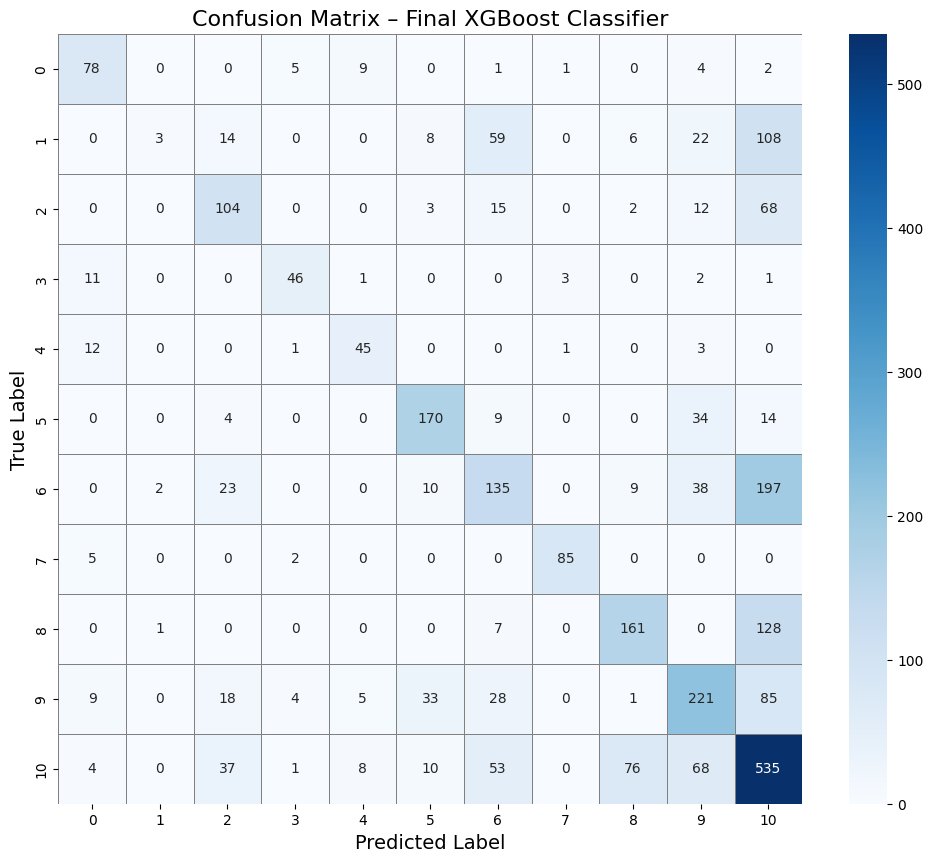

In [7]:
# Tính confusion matrix
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar=True
)

plt.title("Confusion Matrix – Final XGBoost Classifier", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

**Nhận xét:**
- Class 5, 7 và đặc biệt class 10 có số lượng dự đoán đúng rất cao (ô chéo chính đậm), cho thấy XGBoost phân biệt rất tốt những thể loại có đặc trưng âm thanh rõ rệt.

- Class 2, 3 và 4 cũng được dự đoán khá ổn định: 104, 46 và 45 mẫu đúng.

- Class 0 và Class 9 có độ chính xác tương đối, nhưng vẫn có mức nhầm lẫn đáng kể sang các class lớn như 10 và 5.

- Class 1, 6 và 8 dự đoán kém hơn.

**Kết luận:**
- XGBoost phân loại rất tốt các genre có đặc trưng rõ (5, 7, 10).

- Một số lớp vẫn nhầm lẫn nặng (1, 6, 8, 9) do đặc trưng tương đồng hoặc dữ liệu imbalance.

- Feature engineering giúp cải thiện kết quả, nhưng hạn chế vẫn xuất hiện ở những thể loại có profile âm thanh gần nhau hoặc ít mẫu.

In [8]:
import joblib
joblib.dump(final_xgb_model, "XGB_model_best_final.pkl")
print("Model saved as XGB_model_best_final.pkl")

Model saved as XGB_model_best_final.pkl


In [9]:
import pandas as pd

test_org = pd.read_csv("../../data03/test.csv")
X_test = test.copy()

In [10]:
# Tạo mô hình XGBoost với tham số tối ưu đã tìm được
final_model = XGBClassifier(
    learning_rate    = 0.029871568153417245,
    max_depth        = 5,
    n_estimators     = 280,
    subsample        = 0.88453678109946,
    colsample_bytree = 0.908897907718663,
    min_child_weight = 3,
    
    objective        = "multi:softprob",
    eval_metric      = "mlogloss",
    tree_method      = "hist",
    n_jobs           = -1,
    random_state     = 42
)

# Train mô hình
final_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.908897907718663
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [12]:
test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "Id": test_org["Id"],
    "Class": test_pred
})

submission.to_csv("submission_xgb.csv", index=False)
print("File submission_xgb.csv đã được tạo!")

File submission_xgb.csv đã được tạo!
